#**Pipeline**

In [19]:
import subprocess, sys

#installing non-standard packages
for pkg in ["pymongo", "xgboost", "holidays"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

df = pd.read_csv("pjm_demand_clean.csv")

##**Data Preparation - MongoDB Querying**

In [21]:
import pandas as pd
import holidays
import logging
from pymongo import MongoClient, errors

#db configuration
MONGO_URI = "mongodb+srv://<username>:<password>@cluster0.nr0mo.mongodb.net/?appName=Cluster0"
DB_NAME   = "ds4320_project2"
COLL_NAME = "pjm_demand"

#update logging
logging.info("Starting MongoDB upload")

#reshaping hourly df into one document per day with nested hours array
def build_daily_documents(df):
    #building a US holiday set covering the date range
    us_holidays = holidays.US(years=range(2023, 2026))

    documents = []
    df["date_str"] = df["datetime"].dt.strftime("%Y-%m-%d")

    for date_str, group in df.groupby("date_str"):
        group = group.sort_values("datetime")

        #skip any day that does not have a full 24 hours of demand data
        if group["demand_mw"].isna().any():
            logging.warning(f"Skipping {date_str}: missing demand_mw values")
            continue

        dt = group["datetime"].iloc[0]

        #building the nested hours array
        hours_array = []
        for _, row in group.iterrows():
            hours_array.append({
                "hour":      int(row["datetime"].hour),
                "demand_mw": round(float(row["demand_mw"]), 1),
                #solar_mw and wind_mw may be null per schema
                "solar_mw":  round(float(row["solar_mw"]), 1) if pd.notna(row["solar_mw"]) else None,
                "wind_mw":   round(float(row["wind_mw"]),  1) if pd.notna(row["wind_mw"])  else None,
            })

        doc = {
            "date":                date_str,
            "year":                int(dt.year),
            "month":               int(dt.month),
            "dow":                 int(dt.weekday()),          #where 0=Monday, 6=Sunday
            "is_holiday":          1 if date_str in us_holidays else 0,
            "daily_avg_demand_mw": round(float(group["demand_mw"].mean()), 1),
            "daily_peak_demand_mw":round(float(group["demand_mw"].max()),  1),
            "hours":               hours_array,
        }
        documents.append(doc)

    logging.info(f"Built {len(documents)} daily documents")
    return documents

#connecting to mongodb to bulk insert daily docs
def upload_to_mongo(documents, uri, db_name, coll_name):
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=10000)
        client.admin.command("ping")           #verifying connection
        logging.info("MongoDB connection successful")
    except errors.ServerSelectionTimeoutError as e:
        logging.error(f"MongoDB connection failed: {e}")
        raise

    db   = client[db_name]
    coll = db[coll_name]

    #ensuring unique index on date so re-runs are safe
    coll.create_index("date", unique=True)

    try:
        result = coll.insert_many(documents, ordered=False)
        inserted = len(result.inserted_ids)
        logging.info(f"Inserted {inserted} documents into {coll_name}")
        print(f"Inserted {inserted} documents into '{coll_name}'")
    except errors.BulkWriteError as bwe:
        #some docs may be duplicates, report how many were actually new
        inserted = bwe.details.get("nInserted", 0)
        logging.warning(f"Bulk write partial: {inserted} inserted, some duplicates skipped")
        print(f"Partial insert: {inserted} new documents (duplicates skipped)")

    client.close()

#querying all documents from pjm_demand and opening nested hours array into a flat hourly dataframe ready w/ one doc per hour
def query_to_dataframe(uri, db_name, coll_name):
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=10000)
        client.admin.command("ping")
        logging.info("Connected to MongoDB for query")
    except Exception as e:
        logging.error(f"Connection failed: {e}")
        raise

    coll = client[db_name][coll_name]
    docs = list(coll.find({}, {"_id": 0}))   #exclude Mongo _id field
    client.close()

    rows = []
    for doc in docs:
        for h in doc["hours"]:
            rows.append({
                "date":                doc["date"],
                "year":                doc["year"],
                "month":               doc["month"],
                "dow":                 doc["dow"],
                "is_holiday":          doc["is_holiday"],
                "daily_avg_demand_mw": doc["daily_avg_demand_mw"],
                "daily_peak_demand_mw":doc["daily_peak_demand_mw"],
                "hour":                h["hour"],
                "demand_mw":           h["demand_mw"],
                "solar_mw":            h["solar_mw"],
                "wind_mw":             h["wind_mw"],
            })

    df = pd.DataFrame(rows)
    df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")
    df = df.sort_values("datetime").reset_index(drop=True)
    logging.info(f"Queried {len(df):,} hourly rows from MongoDB")
    print(f"Loaded {len(df):,} hourly rows from MongoDB")
    return df


#run upload then immediately query back into dataframe
df = pd.read_csv("pjm_demand_clean.csv", parse_dates=["datetime"])
documents = build_daily_documents(df)
print(f"Documents built: {len(documents)}")
upload_to_mongo(documents, MONGO_URI, DB_NAME, COLL_NAME)

df_mongo = query_to_dataframe(MONGO_URI, DB_NAME, COLL_NAME)
df_mongo.head()

Documents built: 1097
Inserted 1097 documents into 'pjm_demand'
Loaded 26,207 hourly rows from MongoDB


,date,year,month,dow,is_holiday,daily_avg_demand_mw,daily_peak_demand_mw,hour,demand_mw,solar_mw,wind_mw,datetime
0,2023-01-01,2023,1,6,1,75383.6,83490.0,6,75969.0,8.0,6657.0,2023-01-01 06:00:00
1,2023-01-01,2023,1,6,1,75383.6,83490.0,7,74622.0,8.0,5851.0,2023-01-01 07:00:00
2,2023-01-01,2023,1,6,1,75383.6,83490.0,8,73526.0,8.0,5260.0,2023-01-01 08:00:00
3,2023-01-01,2023,1,6,1,75383.6,83490.0,9,72765.0,8.0,4715.0,2023-01-01 09:00:00
4,2023-01-01,2023,1,6,1,75383.6,83490.0,10,72438.0,8.0,4778.0,2023-01-01 10:00:00


In [22]:
import numpy as np

def engineer_features(df):
    df = df.copy().sort_values("datetime").reset_index(drop=True)

    #cyclical time encoding to capture circular nature of hours and months
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"]  / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"]  / 24)
    df["month_sin"]  = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["month"] / 12)

    #past demand values at the same hour (lag features)
    df["lag_24h"]  = df["demand_mw"].shift(24)    #demand exactly 24 hours ago
    df["lag_48h"]  = df["demand_mw"].shift(48)    #demand 48 hours ago
    df["lag_168h"] = df["demand_mw"].shift(168)   #demand same hour last week

    #rolling means to smooth out noise and capture recent trend
    df["rolling_mean_24h"]  = df["demand_mw"].shift(1).rolling(24).mean()
    df["rolling_mean_168h"] = df["demand_mw"].shift(1).rolling(168).mean()

    #fill renewable nulls with 0 (solar is actually 0 at night)
    df["solar_mw"] = df["solar_mw"].fillna(0)
    df["wind_mw"]  = df["wind_mw"].fillna(0)

    #dropping rows where lag features are NaN
    df = df.dropna(subset=["lag_24h", "lag_48h", "lag_168h",
                            "rolling_mean_24h", "rolling_mean_168h"])
    df = df.reset_index(drop=True)
    logging.info(f"Feature engineering complete: {len(df):,} rows")
    return df


df_features = engineer_features(df_mongo)

FEATURE_COLS = [
    "year", "month", "dow", "hour", "is_holiday",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "lag_24h", "lag_48h", "lag_168h",
    "rolling_mean_24h", "rolling_mean_168h",
    "solar_mw", "wind_mw"
]
TARGET = "demand_mw"

print(f"Feature matrix shape: {df_features[FEATURE_COLS].shape}")
df_features[FEATURE_COLS + [TARGET]].head()

Feature matrix shape: (26039, 16)


,year,month,dow,hour,is_holiday,hour_sin,hour_cos,month_sin,month_cos,lag_24h,lag_48h,lag_168h,rolling_mean_24h,rolling_mean_168h,solar_mw,wind_mw,demand_mw
0,2023,1,6,6,0,1.000000,6.123234e-17,0.5,0.866025,86984.0,82476.0,75969.0,90346.458333,85390.940476,32.0,760.0,87225.0
1,2023,1,6,7,0,0.965926,-2.588190e-01,0.5,0.866025,85364.0,81605.0,74622.0,90356.500000,85457.940476,32.0,836.0,86081.0
2,2023,1,6,8,0,0.866025,-5.000000e-01,0.5,0.866025,84448.0,81298.0,73526.0,90386.375000,85526.148810,32.0,1088.0,86581.0
3,2023,1,6,9,0,0.707107,-7.071068e-01,0.5,0.866025,84285.0,81537.0,72765.0,90475.250000,85603.857143,32.0,969.0,86847.0
4,2023,1,6,10,0,0.500000,-8.660254e-01,0.5,0.866025,84950.0,81354.0,72438.0,90582.000000,85687.678571,11.0,1095.0,86718.0


In [23]:
#dropping 6 rows from 2026 (incomplete year)
df_features = df_features[df_features["year"] < 2026].reset_index(drop=True)

#confirmation of drop
print(df_features["year"].value_counts().sort_index())
print("Date range:", df_features["datetime"].min(), "→", df_features["datetime"].max())

year
2023    8561
2024    8737
2025    8735
Name: count, dtype: int64
Date range: 2023-01-08 06:00:00 → 2025-12-31 23:00:00


##**Solution Analysis**

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import logging

#chronological split, train on data before test_year, test on test_year
def train_test_split_temporal(df, test_year=2025):
    train = df[df["year"] < test_year].copy()
    test  = df[df["year"] == test_year].copy()
    logging.info(f"Train rows: {len(train):,} | Test rows: {len(test):,}")
    print(f"Train: {len(train):,} rows ({train['date'].min()} to {train['date'].max()})")
    print(f"Test:  {len(test):,}  rows ({test['date'].min()}  to {test['date'].max()})")
    return train, test

#xgboost model to handle tabular lag-feature data
def train_xgboost(train, feature_cols, target):
    X_train = train[feature_cols]
    y_train = train[target]

    model = XGBRegressor(
        n_estimators=500,        #number of boosting rounds
        learning_rate=0.05,      #low rate improves generalization
        max_depth=6,
        subsample=0.8,           #row sampling per tree (reduces overfitting)
        colsample_bytree=0.8,    #feature sampling per tree
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X_train, y_train)
    logging.info("XGBoost model trained")
    print("Model trained")
    return model

#generating predictions on test set to compute MAE/MAPE
def evaluate_model(model, test, feature_cols, target):
    X_test = test[feature_cols]
    y_test = test[target]

    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    mape  = mean_absolute_percentage_error(y_test, preds) * 100  # as percent

    test = test.copy()
    test["predicted_mw"] = preds

    logging.info(f"Test MAE: {mae:,.1f} MW | MAPE: {mape:.2f}%")
    print(f"\nTest Results (2025)")
    print(f"  MAE:  {mae:,.1f} MW")
    print(f"  MAPE: {mape:.2f}%")
    return test, mae, mape


#running model
train_df, test_df = train_test_split_temporal(df_features, test_year=2025)
model             = train_xgboost(train_df, FEATURE_COLS, TARGET)
results_df, mae, mape = evaluate_model(model, test_df, FEATURE_COLS, TARGET)

Train: 17,298 rows (2023-01-08 to 2024-12-31)
Test:  8,735  rows (2025-01-01  to 2025-12-31)
Model trained

Test Results (2025)
  MAE:  3,300.5 MW
  MAPE: 3.30%


In [25]:
from pymongo import MongoClient, errors
import logging

PRED_COLL = "pjm_predictions"

#storing model predictions in mongodb w/ predicted vs. actual demand
def upload_predictions(results_df, uri, db_name, pred_coll):
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=10000)
        client.admin.command("ping")
    except Exception as e:
        logging.error(f"Connection failed: {e}")
        raise

    coll = client[db_name][pred_coll]
    coll.create_index("date", unique=True)

    documents = []
    for date_str, group in results_df.groupby("date"):
        group = group.sort_values("hour")
        hours_array = [
            {
                "hour":         int(row["hour"]),
                "actual_mw":    round(float(row["demand_mw"]),    1),
                "predicted_mw": round(float(row["predicted_mw"]), 1),
                "error_mw":     round(float(row["predicted_mw"] - row["demand_mw"]), 1),
            }
            for _, row in group.iterrows()
        ]
        daily_mape = (
            abs(group["predicted_mw"] - group["demand_mw"]) / group["demand_mw"]
        ).mean() * 100

        documents.append({
            "date":       date_str,
            "year":       int(group["year"].iloc[0]),
            "month":      int(group["month"].iloc[0]),
            "daily_mape": round(daily_mape, 4),
            "hours":      hours_array,
        })

    try:
        result = coll.insert_many(documents, ordered=False)
        print(f"Inserted {len(result.inserted_ids)} prediction documents into '{pred_coll}'")
        logging.info(f"Inserted {len(result.inserted_ids)} prediction docs")
    #in case of duplicate inserts/ re-runs
    except errors.BulkWriteError as bwe:
        print(f"Partial insert: {bwe.details.get('nInserted', 0)} new (duplicates skipped)")

    client.close()

#365 inserts for the year of 2025
upload_predictions(results_df, MONGO_URI, DB_NAME, PRED_COLL)

Inserted 365 prediction documents into 'pjm_predictions'


##**Analysis Rationale**

The data was split chronologically, using 2023 and 2024 for training, and 2025 for testing, because time series data should not be split randomly. A random split would allow the model to train on future hours and then "predict" past ones, producing accuracy scores that look strong in the notebook but would collapse immediately in real-world use. XGBoost was selected as the model because this problem is a structured tabular regression task, where the input is a row of engineered features per hour, not raw sequential data, which means gradient boosting outperforms neural networks at this scale while training in a much less time. The feature set was designed around the two dominant drivers of electricity demand, which are time patterns and recent demand history. Cyclical sine/cosine encodings for hour and month were used to preserve their circular nature, and lag features at 24, 48, and 168 hours to give the model explicit memory of what demand looked like at the same hour yesterday, two days ago, and last week. MAPE was chosen as the evaluation metric because it is the industry standard in energy forecasting and expresses error as a percentage of actual demand, which makes results interpretable and comparable across seasons.

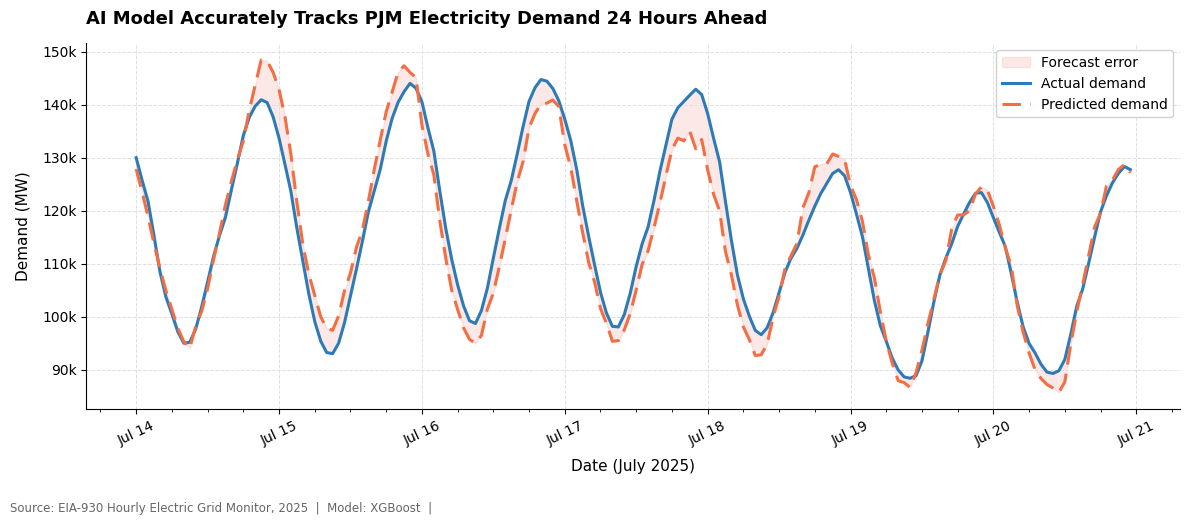

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_press_release(results_df, mae, mape):
    results_df = results_df.copy()
    results_df["datetime"] = (
        pd.to_datetime(results_df["date"]) +
        pd.to_timedelta(results_df["hour"], unit="h")
    )
    results_df = results_df.sort_values("datetime")

    #sample week from summer with higher peaks
    sample_start = pd.Timestamp("2025-07-14")
    sample_end   = pd.Timestamp("2025-07-21")
    week = results_df[
        (results_df["datetime"] >= sample_start) &
        (results_df["datetime"] <  sample_end)
    ]

    #plot style
    plt.rcParams.update({
        "font.family":    "DejaVu Sans",
        "font.size":      12,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.color":        "#e0e0e0",
        "grid.linewidth":    0.7,
        "grid.linestyle":    "--",
    })

    fig, ax = plt.subplots(figsize=(12, 5))

    #shaded error band between actual and predicted
    ax.fill_between(week["datetime"], week["demand_mw"], week["predicted_mw"],
     alpha=0.12, color="#e74c3c", label="Forecast error")

    #actual and predicted lines
    ax.plot(week["datetime"], week["demand_mw"], label="Actual demand",
      color="#2c7bb6", linewidth=2.2)

    ax.plot(week["datetime"], week["predicted_mw"], label="Predicted demand",
      color="#f46d43", linewidth=2.2, linestyle="--", dashes=(6, 3))

    #label/formatting
    ax.set_title(
        "AI Model Accurately Tracks PJM Electricity Demand 24 Hours Ahead",
        fontsize=13, fontweight="bold", pad=14, loc="left"
    )
    ax.set_xlabel("Date (July 2025)", fontsize=11, labelpad=8)
    ax.set_ylabel("Demand (MW)", fontsize=11, labelpad=8)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.tick_params(axis="x", rotation=25, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    #legend and footnote
    ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="#cccccc")

    fig.text(0.01, -0.04, f"Source: EIA-930 Hourly Electric Grid Monitor, 2025  |  Model: XGBoost  |  ",
      fontsize=8.5, color="#666666")

    plt.tight_layout()
    plt.savefig("press_release_chart.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_press_release(results_df, mae, mape)

##**Visualization Rationale**

A single representative week in July 2025 was chosen over a full-year view because the goal of the press release chart is immediate comprehension, not completeness. A year of hourly data at this scale would compress into an unreadable line, while a week clearly shows the model tracking the daily rise and fall of demand hour by hour. July was selected specifically because summer is the most operationally critical period for the PJM grid, when demand swings are largest and forecasting errors are most costly, making it the most compelling test of the model's capability. The shaded error band between the actual and predicted lines was added because it gives a non-technical reader an immediate visual sense of forecast accuracy without requiring them to mentally compute the gap between two lines. By using this chart, the average reader can easily comprehend what the model is doing, noting the actual vs. predicted demand lines, and conclude the similarities between the two with minimal effort. The ease of conclusion and understanding makes this a compelling visualization to everyone, not just a technical reader.